In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
#Leitura dos dados

# idade de aponsentadoria
dados_idade_aposentadoria = pd.read_csv("C:\\Users\\RedSeek\\Desktop\\DATA SCIENCE FORMACAO\\Aplicacao de Teste de Hipoteses\\dados_idade_aposentadoria.csv")

dados_vida_lampada = pd.read_csv("C:\\Users\\RedSeek\\Desktop\\DATA SCIENCE FORMACAO\\Aplicacao de Teste de Hipoteses\\dados_vida_lampada.csv")

# Altura dos funcionarios
dados_alturas = pd.read_csv("C:\\Users\\RedSeek\\Desktop\\DATA SCIENCE FORMACAO\\Aplicacao de Teste de Hipoteses\\dados_alturas.csv")

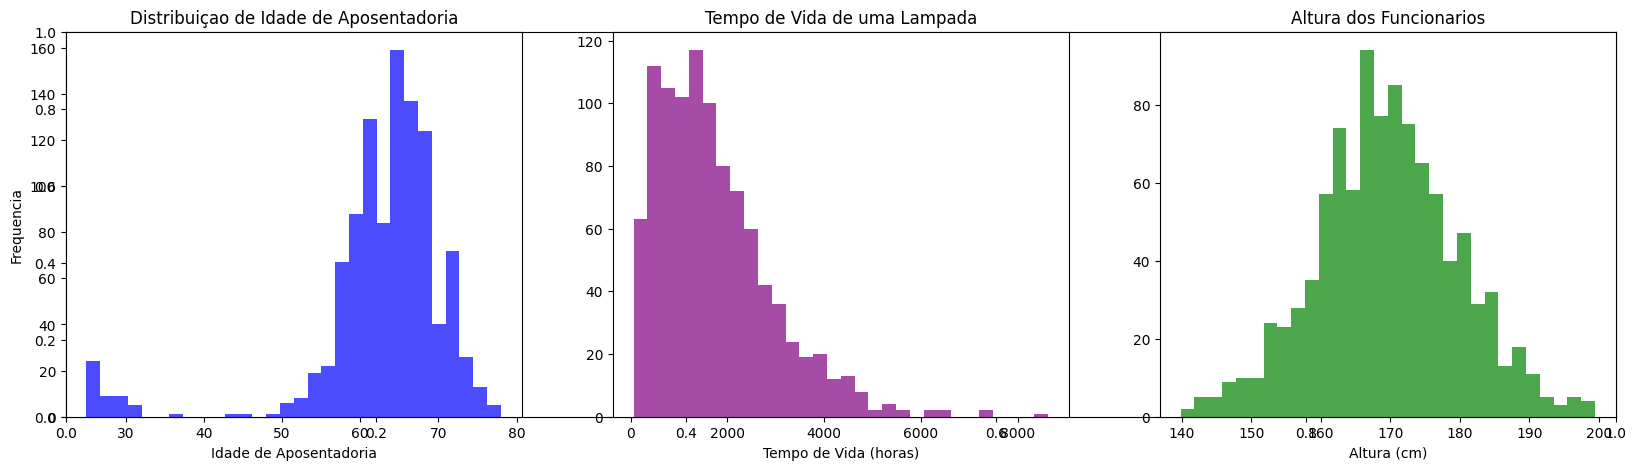

In [34]:
#variaveis de distribuiçoes
plt.subplots(figsize=(20,5))
plt.subplot(131)
plt.title("Distribuiçao de Idade de Aposentadoria")
plt.xlabel('Idade de Aposentadoria')
plt.ylabel('Frequencia')
plt.hist(dados_idade_aposentadoria, bins=30, alpha=0.7, color='blue')


plt.subplot(132)
plt.title("Tempo de Vida de uma Lampada")
plt.xlabel('Tempo de Vida (horas)')
plt.hist(dados_vida_lampada, bins=30, alpha=0.7, color='purple')


plt.subplot(133)
plt.title("Altura dos Funcionarios")
plt.xlabel('Altura (cm)')

plt.hist(dados_alturas, bins=30, alpha=0.7, color='green')

plt.show()
 


FAZENDO A REAMOSTRAGEM:

In [35]:
# Reamostragens

# tamanho da amostra
n = 100
# quantidade de amostras
qnt = 100000

# função de reamostragem e cálculo de médias
def reamostragem_media(dados, coluna, n, qnt):
    medias = [dados[coluna].sample(n, replace=True).mean() for _ in range(qnt)]
    return medias

In [36]:
dados_idade_aposentadoria.head()

,idade
0,66
1,66
2,60
3,61
4,57


In [37]:
dados_vida_lampada.head()

,duracao
0,2238.462196
1,404.474833
2,358.025869
3,2193.463611
4,1072.377941


In [38]:
dados_alturas.head()

,alturas
0,167.52
1,185.21
2,172.74
3,171.52
4,157.75


In [39]:
#Realizando as reamostragens com a funçao:
medias_idade = reamostragem_media(dados_idade_aposentadoria, 'idade', n, qnt)
medias_duracao = reamostragem_media(dados_vida_lampada, 'duracao', n, qnt)
medias_altura = reamostragem_media(dados_alturas, 'alturas', n, qnt)

COMPARADANDO AS MEDIAS ORIGINAIS COM AS MEDIAS DAS REAMOSTRAGENS CRIADAS:

In [40]:
print("*****  Médias populacionais *****")

print("idade:", dados_idade_aposentadoria['idade'].mean())
print("duração:", dados_vida_lampada['duracao'].mean())
print("altura:", dados_alturas['alturas'].mean())

*****  Médias populacionais *****
idade: 62.70857142857143
duração: 1731.8036029420002
altura: 169.52022


In [41]:
def Average(lst):
    return sum(lst) / len(lst)

print("*****  Médias pamostrais *****")

print("idade:", Average(medias_idade))
print("duração:", Average(medias_duracao))
print("altura:", Average(medias_altura))

*****  Médias pamostrais *****
idade: 62.704806299999206
duração: 1731.5015769681856
altura: 169.52376634700138


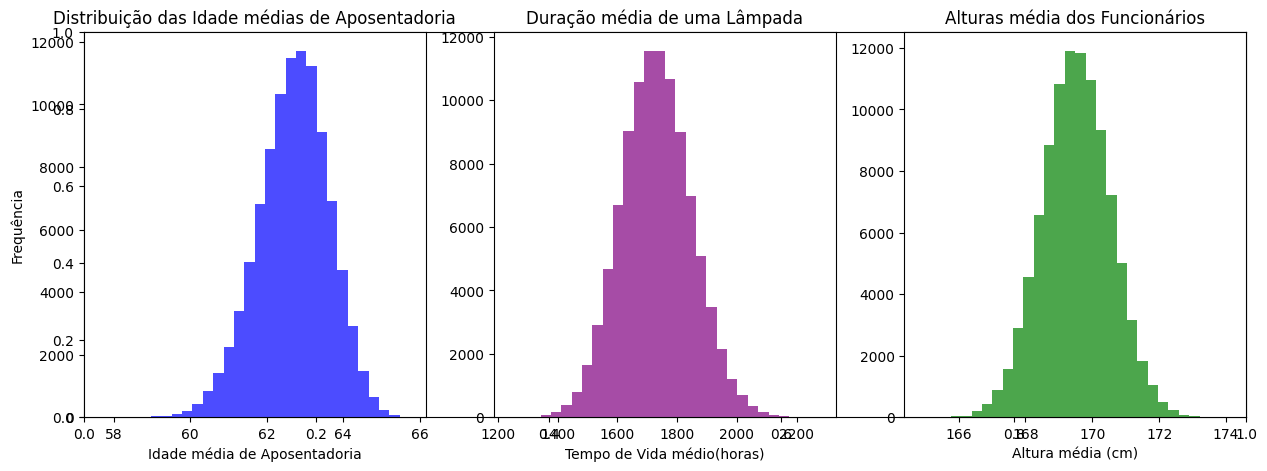

In [42]:
plt.subplots(figsize=(15, 5))
plt.subplot(131)
plt.title('Distribuição das Idade médias de Aposentadoria')
plt.xlabel('Idade média de Aposentadoria')
plt.ylabel('Frequência')
plt.hist(medias_idade, bins=30, alpha=0.7, color='blue')

plt.subplot(132)
plt.hist(medias_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio(horas)')

plt.subplot(133)
plt.hist(medias_altura, bins=30, alpha=0.7, color='green')
plt.title('Alturas média dos Funcionários')
plt.xlabel('Altura média (cm)')

plt.show()

In [43]:
# média da nova amostra
media_nova_amostra = 1200

In [44]:
# media original
dados_vida_lampada['duracao'].mean()

np.float64(1731.8036029420002)

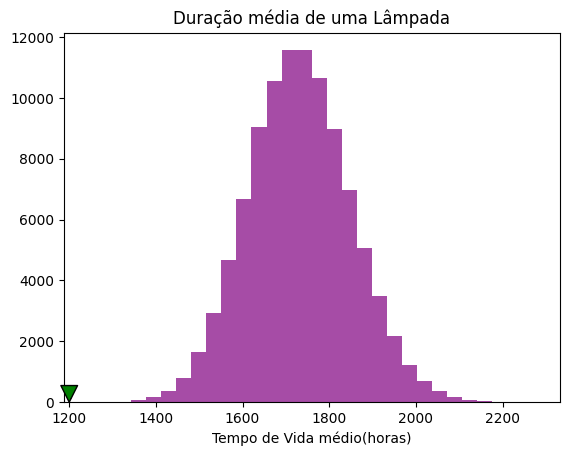

In [45]:
# Quão distante essa média está do comportamento?

plt.hist(medias_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio(horas)')
plt.annotate('.', xy=(media_nova_amostra, 0), xytext=(media_nova_amostra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

In [47]:
# transformando medias_duração em DataFrame
duracao_amostras = pd.DataFrame({'medias_duracao': medias_duracao})

In [48]:
# calculando informações
media_das_medias = duracao_amostras['medias_duracao'].mean()
EP = duracao_amostras['medias_duracao'].std()

print("*****  Medidas amostrais *****")
print("média:", media_das_medias )
print("Erro Padrão:", EP )

*****  Medidas amostrais *****
média: 1731.5015769681993
Erro Padrão: 118.25955373574715


In [49]:
# Quantos erros?
1732 - EP

np.float64(1613.7404462642528)

In [50]:
# Quantos erros?
1732 - 3*EP

np.float64(1377.2213387927586)

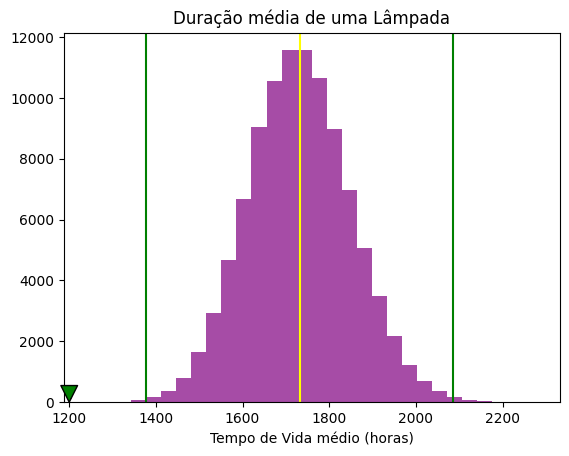

In [51]:
# Visualizando a quantidade de amostras entre 3EP +- da média.

plt.hist(medias_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio (horas)')
plt.axvline(media_das_medias, color = "yellow")
plt.axvline(media_das_medias + 3*EP , color = "green")
plt.axvline(media_das_medias - 3*EP , color = "green")
plt.annotate('.', xy=(media_nova_amostra, 0), xytext=(media_nova_amostra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

In [56]:
#quanto está no intervalo de +ou- dois desvio
qnt_obs = duracao_amostras[(duracao_amostras > media_das_medias - 3*EP) &
                          (duracao_amostras < media_das_medias + 3*EP)]

In [57]:
# quanto isso representa?
qnt_obs.count()/duracao_amostras.count()

medias_duracao    0.99707
dtype: float64

In [58]:
# quanto isso representa?
qnt_obs.count()/duracao_amostras.count()*100

medias_duracao    99.707
dtype: float64

In [62]:
# importando o stats
from scipy import stats

In [63]:
# levar em consideração essa amostra
dados_vida_lampada

# nível de confiança definido
confianca = 0.95

In [64]:
#informações para o IC

media = dados_vida_lampada['duracao'].mean()
desvio_padrao_amostral = dados_vida_lampada['duracao'].std()
tamanho_amostra = len(dados_vida_lampada)

In [65]:
intervalo_confianca = stats.norm.interval(confianca)

In [66]:
# Calculando intervalo de confiança

intervalo_confianca = stats.norm.interval(confianca,
                                       loc=media ,
                                       scale=desvio_padrao_amostral/np.sqrt(tamanho_amostra))

In [67]:
# Visualizando os resultados

print("IC (95%):", intervalo_confianca)

IC (95%): (np.float64(1658.3741665835487), np.float64(1805.2330393004518))
